# Toy problem: RV-SDDP versus Cyclic SDDP

This notebook reproduces the numerical experiments on the toy problem presented in the accompanying paper. The problem is a simple infinite-horizon discounted reservoir management problem used to illustrate the convergence behavior of the proposed **RV-SDDP** algorithm and to compare it with **Cyclic SDDP**, i.e., the variant without shifts.

In [1]:
import Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [2]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using Statistics
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)
using LaTeXStrings

[ Info: Precompiling RVSDDP [7c8f0945-522d-4538-8433-0d76605ce121] (cache misses: wrong dep version loaded (4))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (18))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (12))
[ Info: Precompiling Gurobi [2e9cd046-0924-5485-92f1-d5272153d98b] (cache misses: wrong dep version loaded (18))


Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05
Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


## Run RV-SDDP and Cyclic SDDP

In [3]:
discount_factor=0.99
period = 1
graph=RVSDDP.InfiniteLinearGraph(period);

In [4]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    @variable(subproblem, 0 <= volume <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation >= 0
        hydro_generation >= 0
        hydro_spill >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 90.0]
    P = [1 / length(Ω) for _ in Ω]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            volume.out == volume.in - hydro_generation - hydro_spill + inflow
            hydro_generation <= 100
            thermal_generation <= 30
            deficit + hydro_generation + thermal_generation == 60
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 50*hydro_spill + 50 * deficit+ 2*thermal_generation)
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [11]:
model_cyclic_sddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_cyclic_sddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 100, infinite = true, shift_function=RVSDDP.no_shift); 

In [13]:
model_rvsddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_rvsddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 100, infinite = true, shift_function=RVSDDP.shift_update_random_forward); 

## Comparison of value function approximations obtained by RV-SDDP and cyclic SDDP after 100 iterations.

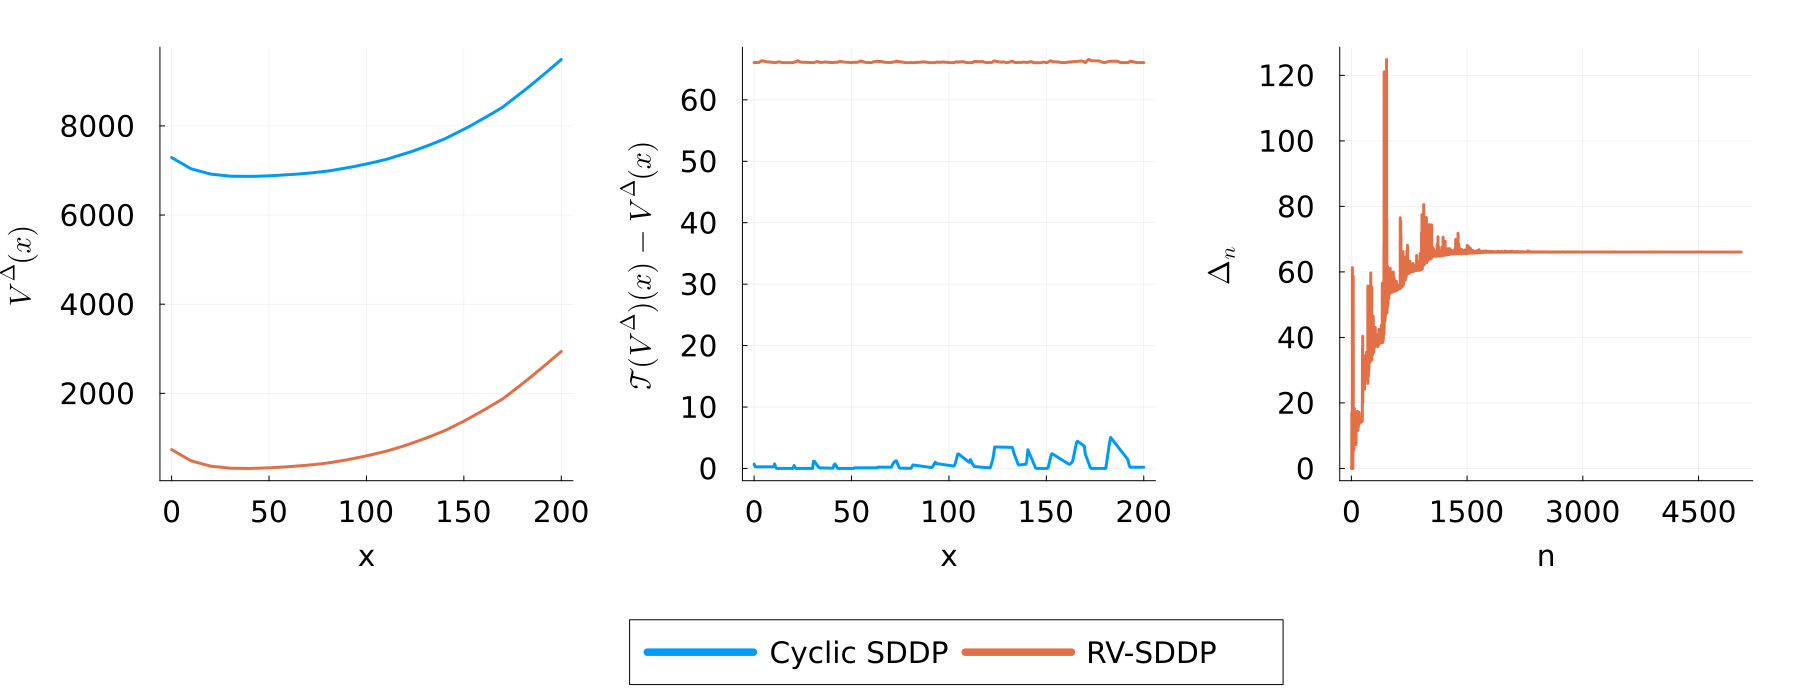

In [15]:
fontsize = 20
ind = 0:0.5:200
V_cyclic_sddp = [RVSDDP.compute_V(model_cyclic_sddp[1].value_function, Dict(:volume=>1.0*i)) for i in ind]
TV_cyclic_sddp = [RVSDDP.compute_TV(model_cyclic_sddp[1], Dict(:volume=>1.0*i)) for i in ind]
V_rvsddp = [RVSDDP.compute_V(model_rvsddp[1].value_function, Dict(:volume=>1.0*i)) for i in ind]
TV_rvsddp = [RVSDDP.compute_TV(model_rvsddp[1], Dict(:volume=>1.0*i)) for i in ind]

p1 = plot(
    ind,
    V_cyclic_sddp,
    label = false,
    xlabel = "x",
    ylabel = L"V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p1, ind, V_rvsddp, label = false, linewidth = 3)

p2 = plot(
    ind,
    TV_cyclic_sddp - V_cyclic_sddp,
    label = false,
    xlabel = "x",
    ylabel = L"\mathcal{T}(V^\Delta)(x) - V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p2, ind, TV_rvsddp - V_rvsddp, label = false, linewidth = 3)

p3=plot(label = false, xlabel="n", ylabel =L"\Delta_n",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)

plot!(p3, [cut.shift[1][1] for cut in model_rvsddp[1].value_function.cut_V], xticks = [0, 1500,3000,4500],label=false, linewidth=3, color = 2)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    p3,
    pleg,
    layout = @layout([a b c; d{0.2h}]),
    size = (1800, 700),
)

## Value function approximations produced by cyclic SDDP at different iterations.

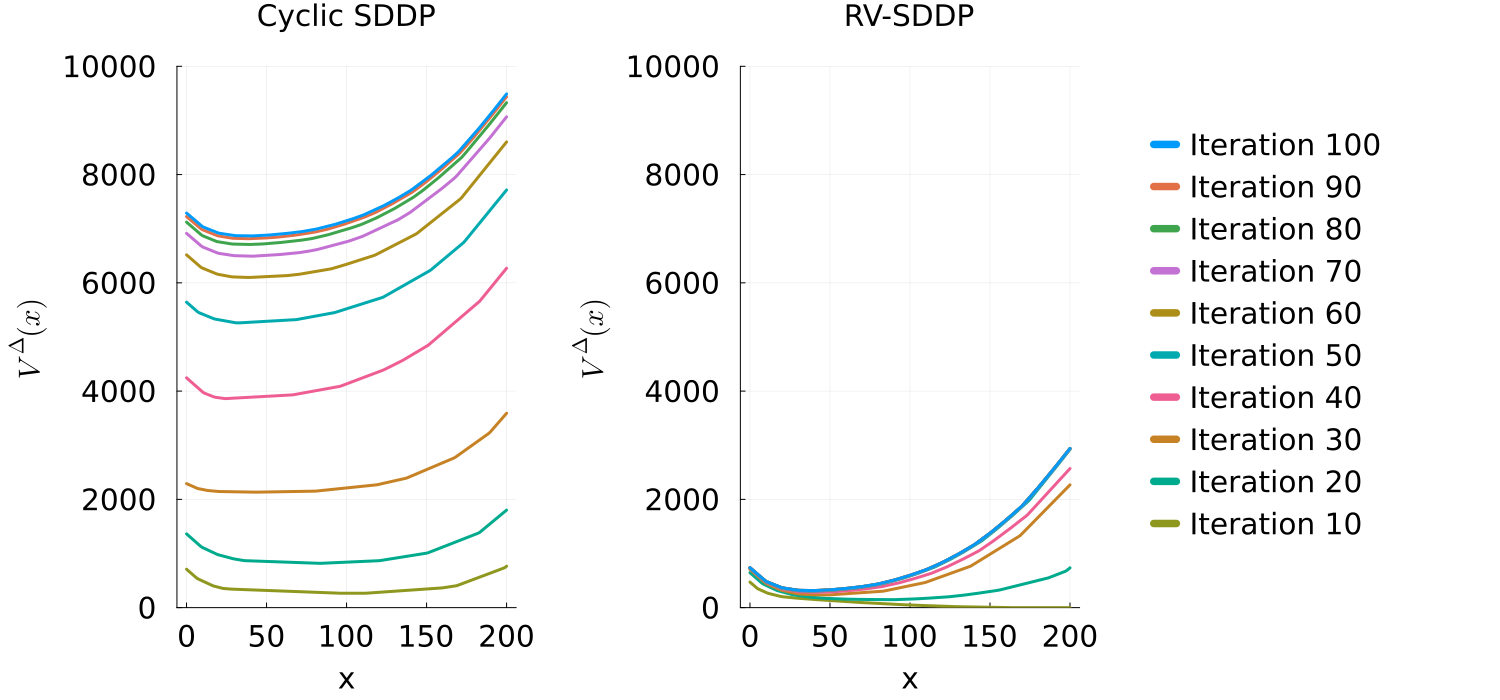

In [18]:
iter_max = 100
model_cyclic_sddp_list = [RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    ) for iter in 10:10:iter_max]

for (i, iter) in enumerate(10:10:iter_max)
    RVSDDP.add_cuts_to_model(model_cyclic_sddp_list[i], model_cyclic_sddp, iter);
end

model_rvsddp_list = [RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    ) for iter in 10:10:iter_max]

for (i, iter) in enumerate(10:10:iter_max)
    RVSDDP.add_cuts_to_model(model_rvsddp_list[i], model_rvsddp, iter);
end

ind = 0:1:200

fontsize = 20

p1=plot(xlabel="x", ylabel = L"V^\Delta(x)", guidefontsize=fontsize, tickfontsize=fontsize, titlefontsize = fontsize,legendfontsize=fontsize, size=(1000, 700), margin=10Plots.mm, ylims = (0, 10000),title = "Cyclic SDDP")
color=10
for i in 1:10
    iter = i*10
    V_cyclic_sddp = [RVSDDP.compute_V(model_cyclic_sddp_list[i][1].value_function, Dict(:volume=>1.0*j)) for j in ind]
    plot!(p1, ind, V_cyclic_sddp, label = false, linewidth = 3, color = color)
    color -= 1
end
p2=plot(xlabel="x", ylabel = L"V^\Delta(x)", guidefontsize=fontsize, tickfontsize=fontsize, titlefontsize = fontsize,legendfontsize=fontsize, size=(1000, 700), margin=10Plots.mm, ylims = (0, 10000),title = "RV-SDDP")
color=10
for i in 1:10
    iter = i*10
    V_rvsddp = [RVSDDP.compute_V(model_rvsddp_list[i][1].value_function, Dict(:volume=>1.0*j)) for j in ind]
    plot!(p2, ind, V_rvsddp, label = false, linewidth = 3, color = color)
    color -= 1
end

pleg = plot(
    [NaN], [NaN],
    label = " Iteration 100",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :left,
    legend_columns = 1,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
    showaxis = false,
    foreground_color_legend = nothing,
    background_color_legend = nothing,
    extra_kwargs = Dict(:subplot => Dict(:legend_hfactor => 1.3))
)

color = 2
for k in 2:10
    i = 10 - k + 1
    iter = i * 10

    plot!(
        pleg,
        [NaN], [NaN],
        label = " Iteration $iter",
        linewidth = 3,
        color = color,
    )

    color += 1
end

p_final = plot(
    p1,
    p2,
    pleg,
    layout = @layout([a{0.33w} b{0.33w} c{0.33w}]),
    size = (1500, 700),
)
p_final

## Policy quality and number of active cuts after 31 iterations

The policy quality is evaluated by Monte Carlo simulation over \(N\) scenarios. For \(N=1000\), one evaluation takes approximately 2 minutes. The estimated policy costs are 7382 for Cyclic SDDP and 6942 for RV-SDDP.

In [19]:
N = 1000
TimeHorizon = Int(ceil(log(0.001)/(log(discount_factor))))

688

In [20]:
model_cyclic_sddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_cyclic_sddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 31, infinite = true, shift_function=RVSDDP.no_shift); 

In [21]:
Random.seed!(12345)

simulations_cyclic_sddp= RVSDDP.simulate(
        model_cyclic_sddp,
        N;
        sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
)
println("Average cost for cyclic SDDP: ", mean([sum((discount_factor^(t-1))*simulations_cyclic_sddp[k][t][:stage_objective] for t in 1:TimeHorizon) for k in 1:N]))

Average cost for cyclic SDDP: 7382.470042330939


In [23]:
model_rvsddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_rvsddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 31, infinite = true, shift_function=RVSDDP.shift_update_random_forward); 

In [24]:
Random.seed!(12345)

simulations_rvsddp= RVSDDP.simulate(
        model_rvsddp,
        N;
        sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
)
println("Average cost for RVSDDP: ", mean([sum((discount_factor^(t-1))*simulations_rvsddp[k][t][:stage_objective] for t in 1:TimeHorizon) for k in 1:N]))

Average cost for RVSDDP: 6941.714063279653
